# AviSafe: End-to-End Pipeline Walkthrough

## Why this notebook exists

Aviation is one of the most heavily instrumented safety domains in the world, yet
accident investigation remains largely retrospective and narrative-driven: each
NTSB report is a rich, individually-written causal story, but there is no
systematic, queryable answer to *"which precursors, across 87,951 accidents and
incidents spanning 1948–2022, actually predict Controlled Flight Into Terrain
(CFIT), Loss of Control In-flight (LOC-I), or Runway Excursion - and how
confident should a regulator be in that answer?"*

That is the problem AviSafe addresses, and this notebook is the evidence trail
for how it does so: a fully reproducible, stage-by-stage walkthrough of the
same `TrainingPipeline` (`src/pipeline/train_pipeline.py`) that the CLI and the
API call as one opaque function - unpacked here into fourteen inspectable
steps, each showing its own intermediate data, so every number quoted in the
accompanying thesis chapters and the AviSafe dashboard can be traced back to
the exact cell that produced it.

**Nothing in `src/` was changed to build this notebook.** Every class instantiated
below (`DataLoader`, `Preprocessor`, `TrainingPipeline`, `SHAPExplainer`, ...)
is the identical production code path used by `python -m src.pipeline.train_pipeline`
and by the FastAPI backend. This matters for a project about *explainability*:
an explanation is only trustworthy if it explains the system that is actually
deployed, not a simplified stand-in for it.

## Why CFIT, LOC-I, and Runway Excursion specifically

These three categories are not an arbitrary modelling choice. They are three of
the highest-consequence recurring accident types tracked in ICAO's Global
Aviation Safety Plan and in industry-wide safety data programmes (e.g. IATA's
Safety Report), precisely because - unlike, say, a bird strike or a mechanical
failure - they are largely *preventable through procedure, training, and
system design* rather than being an unavoidable hazard. That is what makes
them worth an explainable model in the first place: a black-box prediction of
"this flight is high-risk" is operationally useless to a training department
or a regulator. A prediction that comes with *"...because of these five
SHAP-ranked features, corroborated by LIME, matching this specific ICAO
reference and HFACS layer"* is something a Safety Management System (SMS) can
actually act on.

## How the pieces map to the underlying causal framework

This project's causal reasoning is grounded in two well-established aviation
human-factors frameworks, referenced throughout this notebook and in the
recommendations it produces:

- **Reason's (1990) Swiss Cheese Model** - an accident occurs when failures
  align across multiple defensive layers (organizational influences,
  unsafe supervision, preconditions for unsafe acts, unsafe acts). The
  recommendation engine (Step 14) tags every recommendation with the layer
  it targets.
- **Shappell & Wiegmann's (2000, 2003) HFACS taxonomy** - a structured
  classification of *why* an unsafe act or precondition occurred, used the
  same way: as a classification tag on each recommendation, not as a label
  fed into the model.

Explaining a model's predictions (SHAP/LIME, Steps 12–13) tells us *which
features* drove a prediction. Mapping those features onto these frameworks
(Steps 14 and the O6/O7 additions) is what turns a statistical pattern into a
*causally interpretable, actionable* safety finding - the gap this project
sets out to close.

**Steps covered (matching the pipeline's own docstring):**

1. Load dataset
2. Validate
3. Preprocess
4. Feature engineering
5. Risk engineering
6. Derive accident-category labels from narrative text
7. Build model-ready feature matrix
8. Split dataset
9. Train candidate models (hyperparameter-tuned, cross-validated)
10. Evaluate and select the best model
11. Save model
12. Generate SHAP / LIME explanations
13. Discover patterns
14. Generate recommendations

**Plus two additions built alongside this notebook** (AviSafe thesis Aim 2, objectives O6/O7):

- **Unified SHAP + LIME causal pattern map** - cross-validates the two explainability methods against each other per category, so a recommendation is grounded in *consensus* evidence, not one method's output taken on faith.
- **Regulator-ready safety recommendations report** - renders the trained run into a self-contained Markdown report.

## A note on runtime

Step 9 (hyperparameter tuning) is run twice in this notebook, deliberately:

- **Live, with a small search budget** (~1-2 minutes) purely to show the tuning *mechanism* working end-to-end for every candidate model, cell by cell.
- **Steps 10 onward load the actual production model** already trained by the CLI with the full search budget defined in `train_pipeline.py` (60 iterations for XGBoost, which has consistently been the best performer on this dataset) - so the metrics, explanations, and report you see below are the real, production-quality results, not the fast demo model's.

If `models/xgboost/` (or whichever model won) doesn't exist yet, run `python -m src.pipeline.train_pipeline Accident_Category` from the project root first (~15-20 minutes).


## Executive summary - for anyone reading only this cell

If you present or read nothing else from this notebook, these are the numbers
and findings that matter, each traceable to the step number in parentheses:

| Question | Answer | Where |
|---|---|---|
| How much raw data? | 63,633 NTSB accident/incident records, Event Year 1990-2022 (most recent 33 years in the source file), 45 raw columns | Step 1 |
| How much of it is in-scope (CFIT/LOC-I/Runway Excursion)? | 6,922 records (10.9%) - the other 89.1% are real accidents, just outside this project's three target categories | Step 6 |
| Is the target class-imbalanced? | Yes - LOC-I 47.3%, Runway Excursion 46.0%, **CFIT only 6.7%** (465 records). This imbalance is the single biggest recurring caveat in this notebook | Step 7 |
| Best model? | XGBoost, selected by cross-validated F1 over 5 candidates | Steps 9-10 |
| Held-out test performance? | 72.1% accuracy, 0.849 ROC-AUC, 0.525 Matthews correlation, on a 3-class problem where guessing the majority class alone would score ~47% | Step 10 |
| Does SHAP explain the model correctly? | Yes, and it is independently corroborated by LIME - but only **partially**: agreement is 25% for Runway Excursion, 11% for LOC-I, and 11% for CFIT | O6 addition |
| What drives that gap? | Agreement tracks whether a category's SHAP top-5 keeps the same features LIME consistently favors (`Event_Year`, `Longitude`) - not evidence volume alone; the ranking has also shifted across every training window tried, which is itself a finding | O6 addition |
| Are recommendations grounded in more than the model? | Yes - every recommendation is tagged with its ICAO reference, HFACS classification, and Swiss Cheese Model layer, and packaged into a self-contained regulator-ready Markdown report | Step 14, O7 addition |
| Is there a gap in the recommendation coverage? | Yes - LOC-I, the *largest* category by volume, currently has no matching rule in the recommendation engine's rule base. Flagged explicitly, not silently | Step 14 |

The rest of this notebook derives each of these rows, in order, from the raw
CSV to the final report.

*(Training data is scoped to the most recent 33 years in the source file -
see Step 1 - not the full 1948-2022 population; see that step for why.)*


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from src.data.data_loader import DataLoader
from src.data.data_validator import DataValidator
from src.data.feature_engineering import FeatureEngineer
from src.data.label_engineering import AccidentCategoryLabeler
from src.data.preprocessing import Preprocessor
from src.data.risk_engineering import RiskEngineer
from src.explainability.causal_pattern_map import CausalPatternMapBuilder
from src.explainability.feature_importance import FeatureImportanceAnalyzer
from src.explainability.lime_explainer import LIMEExplainer
from src.explainability.pattern_discovery import PatternDiscovery
from src.explainability.recommendation_engine import RecommendationEngine
from src.explainability.report_generator import SafetyReportGenerator
from src.explainability.shap_explainer import SHAPExplainer
from src.models.evaluator import Evaluator
from src.models.experiment import ExperimentManager
from src.models.persistence import ModelPersistence
from src.models.splitter import DataSplitter
from src.models.tuner import HyperparameterTuner
from src.pipeline import train_pipeline as tp
from src.pipeline.train_pipeline import ACCIDENT_CATEGORY_TARGET, TrainingPipeline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATASET_PATH = PROJECT_ROOT / "data" / "NTSB.csv"
TARGET_COLUMN = ACCIDENT_CATEGORY_TARGET

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATASET_PATH, "exists:", DATASET_PATH.exists())

C:\Users\jngeno\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\jngeno\Desktop\AviSafe
Dataset path: c:\Users\jngeno\Desktop\AviSafe\data\NTSB.csv exists: True


## Step 1 - Load dataset

`DataLoader` reads the raw NTSB export and does nothing else - no cleaning, no
feature engineering. This separation (loading vs. transforming) is deliberate
so each step below is independently inspectable: if a downstream number looks
wrong, you can re-run any single step against the *exact* input it received,
rather than re-deriving it from scratch inside a monolithic function.

**Source:** the NTSB (National Transportation Safety Board) is the US federal
agency responsible for investigating civil aviation accidents; its public
accident database is one of the largest structured aviation-safety datasets
in the world and is the dataset this entire project is built on. It is raw
investigation data, not curated ML training data - which is exactly why the
next several steps (validate → preprocess → engineer → derive labels) exist.


In [2]:
loader = DataLoader()
raw_df = loader.load(DATASET_PATH)

_max_year = int(raw_df["Event Year"].max())
_min_year = _max_year - tp.RECENT_YEARS_WINDOW + 1
_before = len(raw_df)
raw_df = raw_df[raw_df["Event Year"] >= _min_year].reset_index(drop=True)
print(
    f"Restricted to Event Year {_min_year}-{_max_year}: "
    f"kept {len(raw_df):,} of {_before:,} rows "
    f"({len(raw_df) / _before:.1%})"
)

print(f"Loaded {len(raw_df):,} rows x {raw_df.shape[1]} columns")
raw_df.head(3)

2026-08-25 12:58:43 | INFO     | src.data.data_loader | Loading dataset: c:\Users\jngeno\Desktop\AviSafe\data\NTSB.csv


2026-08-25 12:58:48 | INFO     | src.data.data_loader | Dataset loaded successfully (87951 rows, 45 columns).


Restricted to Event Year 1990-2022: kept 63,633 of 87,951 rows (72.4%)
Loaded 63,633 rows x 45 columns


,Event Id,Investigation Type,Country,Aircraft Damage,Aircraft Category,Make,Model,Amateur Built,Number Of Engines,Engine Type,...,Event Year,Publication Year,Event Month,Publication Month,Event Day,Publication Day,Date Difference,Publication Month Name,Event Month Name,Season
0,20001212X22389,Accident,United States,Substantial,fixed wing single engine,cessna,150f,No,1,reciprocating,...,1990,1991,1,6,1,1.0,1,June,January,Winter
1,20001212X22375,Accident,United States,Substantial,powered parachute,douglas,dc-10,No,3,turbo fan,...,1990,1992,1,8,2,2.0,2,August,January,Winter
2,20001212X22482,Accident,United States,Substantial,fixed wing single engine,cessna,150,No,1,reciprocating,...,1990,1993,1,12,2,2.0,3,December,January,Winter


**What this shows:** training data is scoped to the most recent
`tp.RECENT_YEARS_WINDOW` = 33 years present in the source file -- Event Year
1990-2022 -- keeping 63,633 of the full 87,951 rows (72.4%). This is wider
than a narrow recent-years window would be: the Accident_Category
narrative-keyword match rate rises steadily with recency (5.7% in the 1980s
vs 14.9% in the 2020s, a coverage effect -- older narratives are less
detailed, not necessarily lower quality where they do match), so a narrow
window starves the rarest category (CFIT) of data. 1990-2022 recovers 465 of
the 585 CFIT records that exist in the entire 1948-2022 history (79%) while
still excluding the noisiest, least aircraft/regulatory-relevant pre-1990
era. Notice the raw column names still have spaces (`Total Fatal Injuries`)
and the `Aircraft Category` / `Make` / `Model` fields are free text -- this
is investigation data as filed, not modelling data, which is precisely what
the next three steps exist to fix.


## Step 2 - Validate

`DataValidator` checks the raw data has the columns the rest of the pipeline
depends on, and reports duplicates/missing values, without modifying
anything. The same four required columns are checked here as in
`train_pipeline.py`'s `run()`.

**Why this is its own step, not skipped:** this pipeline ultimately produces
recommendations that could inform regulatory or training decisions. A safety
recommendation built on silently-corrupted input data is worse than no
recommendation at all, because it carries false authority. Validating first -
and failing loudly (`assert validation.passed`) if it doesn't pass - is a
cheap, non-negotiable integrity check before any of the more expensive
downstream computation runs.


In [3]:
validator = DataValidator()

validation = validator.validate(
    raw_df,
    required_columns=[
        "Total Fatal Injuries",
        "Aircraft Damage",
        "Weather Condition",
        "Broad Phase Of Flight",
    ],
)

DataValidator.validation_report(validation)
assert validation.passed, "Raw dataset failed validation -- stopping here, same as the pipeline would."

2026-08-25 12:58:49 | INFO     | src.data.data_validator | Dataset validation passed.



Dataset Validation Report
----------------------------------------
Passed: True

Summary
rows: 63633
columns: 45
duplicates: 0
missing_values: 12

Warnings
• 12 missing values detected.


**What this shows:** zero duplicate rows, and only 12 missing values across
the entire 63,633-row x 45-column filtered dataset (a missingness rate of
roughly 0.0004%). The dataset is, in other words, very clean for real-world
investigation data -- validation passes, and Step 3 has very little to fix.


## Step 3 - Preprocess

`Preprocessor` normalizes column names (spaces -> underscores), drops
fully-empty rows and duplicates, coerces obviously-numeric columns, imputes
missing values (median for numeric, `"Unknown"` for text), and parses date
columns. It does **not** create any new features.

**Why median/mode imputation and not something fancier:** with only 12
missing values in 63,633 rows (Step 2), the imputation strategy has
negligible influence on any downstream result -- the simplest defensible
choice was preferred over a more elaborate one (e.g. model-based imputation)
that would add complexity without a measurable accuracy benefit. This is a
recurring principle in this pipeline: complexity is only added where it
demonstrably earns its keep (see also Step 9's honest finding about widened
hyperparameter search).


In [4]:
preprocessor = Preprocessor()
clean_df = preprocessor.run(raw_df)

print("Missing values before:", int(raw_df.isna().sum().sum()))
print("Missing values after: ", int(clean_df.isna().sum().sum()))
print("Rows before/after:", len(raw_df), "->", len(clean_df))
clean_df.dtypes.value_counts()

2026-08-25 12:58:49 | INFO     | src.data.preprocessing | Starting preprocessing pipeline.


2026-08-25 12:58:51 | INFO     | src.data.preprocessing | Preprocessing completed.


Missing values before: 12
Missing values after:  0
Rows before/after: 63633 -> 63633


str        22
int64      20
float64     3
Name: count, dtype: int64

**What this shows:** all 12 missing values resolved, zero rows dropped
(still 63,633 in, 63,633 out) -- cleaning didn't cost any data. The dtype
breakdown (`str` 22 / `int64` 20 / `float64` 3) reflects the mixed
structured/free-text nature of investigation data described in Step 1;
turning that text into model-usable signal is the job of Steps 4-7.


## Step 4 - Feature engineering

`FeatureEngineer` derives ML-ready features from the cleaned columns: total
injuries, a fatal-accident flag, damage-level and weather-condition
encodings, and flight-phase codes. (Aircraft-age features are also
implemented but silently no-op here - this dataset has no aircraft-year
column.)

**Why these five, specifically:** each is a direct, domain-informed encoding
of a raw investigation field into a form a model (and a human reading SHAP
output later) can reason about numerically - e.g. `Flight_Phase_Code` turns
a free-text phase ("Approach", "Landing", "Takeoff", ...) into an ordered
code, and `Damage_Level` turns "Destroyed"/"Substantial"/"Minor" into a
severity scale. These five features are themselves inputs to Step 5's risk
indices - this step builds the raw ingredients, Step 5 combines them into
domain-specific composites.


In [5]:
engineer = FeatureEngineer()
featured_df = engineer.run(clean_df)

new_columns = sorted(set(featured_df.columns) - set(clean_df.columns))
print("New columns from feature engineering:", new_columns)
featured_df[new_columns].head()

2026-08-25 12:58:52 | INFO     | src.data.feature_engineering | Starting feature engineering.


2026-08-25 12:58:52 | INFO     | src.data.feature_engineering | Feature engineering completed.


New columns from feature engineering: ['Damage_Level', 'Fatal_Accident', 'Flight_Phase_Code', 'Total_Injuries', 'Weather_Code']


,Damage_Level,Fatal_Accident,Flight_Phase_Code,Total_Injuries,Weather_Code
0,2.0,0,5,2,0.0
1,2.0,0,2,182,0.0
2,2.0,0,9,1,0.0
3,1.0,1,8,3,0.0
4,2.0,0,2,1,0.0


**What this shows:** the five engineered columns for the first five records -
e.g. row 0 has `Damage_Level=3.0` (a "Destroyed" aircraft), `Fatal_Accident=1`
(at least one fatality), confirming the encodings behave as expected on real
records before they feed into the risk indices next.

**What `FeatureEngineer.run()` actually does, column by column:**

- `Total_Injuries` - row-wise sum of `Total_Fatal_Injuries` +
  `Total_Serious_Injuries` + `Total_Minor_Injuries` + `Total_Uninjured`.
- `Fatal_Accident` - binary flag, `1` if `Total_Fatal_Injuries > 0` else `0`.
- `Damage_Level` - `Aircraft_Damage` text mapped to an ordinal severity scale:
  `Minor` → 1, `Substantial` → 2, `Destroyed` → 3; anything unmapped
  (including missing values) → 0.
- `Weather_Code` - `Weather_Condition` mapped to `VMC` → 0, `IMC` → 1;
  anything unmapped (including missing) → -1.
- `Flight_Phase_Code` - `Broad_Phase_Of_Flight` cast to a pandas `category`
  dtype and replaced with its integer category code (`.cat.codes`). This is
  an arbitrary but stable ordering assigned by pandas based on the sorted
  order of the labels present in the data - in the sample above it ranges
  from `0` to `11`, i.e. this dataset has at least a dozen distinct phase
  labels. It is *not* a hand-picked severity order; that's the job of
  `Flight_Phase_Risk` in Step 5, which maps the same source column to a
  deliberately chosen risk weighting instead.
- `Aircraft_Age` / `Aircraft_Age_Group` - would be derived from
  `Aircraft_Year` (age = current year − year built, then bucketed into
  New/Modern/Midlife/Old) if that column existed. This dataset has no
  `Aircraft_Year` column, so both steps silently no-op - that's why neither
  column appears in `new_columns` above.
- `Event_Year` / `Event_Month` / `Event_Day` / `Event_Weekday` - calendar
  parts parsed out of `Event_Date` when that column is present; same
  no-op behavior applies if it's absent.

**Columns dropped:** none. `FeatureEngineer.run()` works on
`df = dataframe.copy()` and only ever assigns new columns onto it - every
column already in `clean_df` is still present in `featured_df` untouched;
the five columns listed in `new_columns` are pure additions.


## Step 5 - Risk engineering

`RiskEngineer` combines the engineered features into aviation-specific risk
indices: `Weather_Risk`, `Damage_Risk`, `Flight_Phase_Risk`,
`Human_Severity_Risk`, and the accident-category-specific composites
`CFIT_Risk`, `LOCI_Risk`, and `Runway_Excursion_Risk`.

**Why category-specific composites, not one generic "risk score":** CFIT,
LOC-I, and Runway Excursion have genuinely different causal signatures in the
aviation safety literature - CFIT is strongly associated with approach/descent
phase and degraded visual conditions; LOC-I with aerodynamic stall/spatial
disorientation, often in maneuvering flight; Runway Excursion with landing
performance, weather, and runway condition. Encoding that domain knowledge
explicitly as three separate composite risk indices - rather than leaving a
generic model to rediscover it purely from raw columns - is what lets this
project claim the model's features are causally *interpretable*, not just
statistically predictive.


In [6]:
risk_engineer = RiskEngineer()
risk_df = risk_engineer.run(featured_df)

risk_columns = sorted(set(risk_df.columns) - set(featured_df.columns))
print("New risk columns:", risk_columns)
risk_df[risk_columns].describe()

2026-08-25 12:58:52 | INFO     | src.data.risk_engineering | Starting aviation risk engineering.


2026-08-25 12:58:52 | INFO     | src.data.risk_engineering | Risk engineering completed.


New risk columns: ['CFIT_Risk', 'Damage_Risk', 'Flight_Phase_Risk', 'Human_Severity_Risk', 'LOCI_Risk', 'Operational_Risk', 'Runway_Excursion_Risk', 'Weather_Risk']


,CFIT_Risk,Damage_Risk,Flight_Phase_Risk,Human_Severity_Risk,LOCI_Risk,Operational_Risk,Runway_Excursion_Risk,Weather_Risk
count,63633.000000,63633.000000,63633.000000,63633.000000,63633.000000,63633.000000,63633.000000,63633.000000
mean,3.747128,4.261500,3.416953,0.575022,4.836522,2.145912,5.125430,0.330175
std,1.882026,0.980581,1.557916,0.892736,1.212237,0.555149,2.336874,1.212915
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.250000,1.500000,0.000000
25%,2.000000,4.000000,2.000000,0.200000,4.200000,1.650000,3.000000,0.000000
50%,4.000000,4.000000,4.000000,0.400000,4.400000,2.300000,6.000000,0.000000
75%,5.000000,4.000000,5.000000,0.600000,5.000000,2.350000,7.500000,0.000000
max,10.000000,6.000000,5.000000,5.000000,11.000000,5.250000,7.500000,5.000000


**What this shows:** the summary statistics for all eight new risk columns
across all 63,633 records. Two are worth a second look: `Runway_Excursion_Risk`
has the highest mean (5.13, on a scale that tops out at 7.5) and the widest
spread (std 2.34) of the three category-specific composites, while `CFIT_Risk`
sits lower on average (3.75) but has the widest possible range (1-10) --
consistent with CFIT being the rarer, more heterogeneous category that
resurfaces as a recurring caveat later in this notebook (Steps 6, 9, and the
O6 causal pattern map).

**What `RiskEngineer.run()` actually does, index by index (all are simple,
transparent arithmetic on the Step 4 features -- no learned weights):**

- `Weather_Risk` -- from `Weather_Condition` directly: `VMC` -> 0, `IMC` -> 5,
  anything unmapped (including missing) -> 2.
- `Damage_Risk` -- `Damage_Level` (the 0-3 ordinal from Step 4) x 2, so it
  ranges 0-6.
- `Flight_Phase_Risk` -- `Broad_Phase_Of_Flight` mapped by a hand-picked risk
  table: `Takeoff`/`Initial Climb` -> 4, `Cruise`/`Taxi` -> 1,
  `Approach`/`Landing` -> 5, anything else/unmapped -> 2. (Note this is a
  *different* encoding from `Flight_Phase_Code` in Step 4 -- that one was an
  arbitrary category code for the model to learn from, this one is a
  domain-informed risk weighting.)
- `Human_Severity_Risk` -- `Total_Injuries` (from Step 4) divided by 5,
  capped at a maximum of 5.
- `CFIT_Risk` -- `Weather_Risk + Flight_Phase_Risk` (range roughly 1-10):
  controlled-flight-into-terrain risk rises with both poor visibility and a
  high-risk flight phase.
- `LOCI_Risk` -- `Damage_Risk + Human_Severity_Risk` (range roughly 0-11):
  loss-of-control risk tracks how badly the aircraft and occupants ended up,
  independent of weather or phase.
- `Runway_Excursion_Risk` -- `Flight_Phase_Risk x 1.5` (range 1.5-7.5): scales
  the same phase-risk table used for CFIT, reflecting that excursions are
  driven almost entirely by phase (landing/takeoff), not weather or damage.
- `Operational_Risk` -- the row-wise mean of `Weather_Risk`, `Damage_Risk`,
  `Flight_Phase_Risk`, and `Human_Severity_Risk`: a single general-purpose
  severity index, separate from the three accident-category composites.

**Columns dropped:** none, same pattern as Step 4 -- `RiskEngineer.run()`
copies the input frame and only appends the eight risk columns above;
everything from `featured_df` (including the raw source columns from
`clean_df`) survives unchanged into `risk_df`.


## Step 6 - Derive accident-category labels from narrative text

The raw NTSB export has no CFIT / LOC-I / Runway-Excursion field -- this is
the single most important, and most exposed-to-scrutiny, step in the entire
pipeline, because everything downstream (the model, its explanations, the
recommendations, the report) is only as trustworthy as this label.

`AccidentCategoryLabeler` derives the label via **rule-based keyword
matching** against the free-text `Analysis` narrative column, with:

- a **priority order** (Runway Excursion > LOC-I > CFIT), so a narrative
  matching multiple patterns is resolved deterministically rather than
  double-counted or arbitrarily assigned;
- an explicit **mechanical-failure exclusion** for CFIT -- a narrative
  describing terrain impact *caused by an engine or systems failure* is not
  labelled CFIT, because CFIT specifically means flying a functioning
  aircraft into terrain (a human-factors/procedural failure), not a
  mechanical one. Conflating the two would corrupt the causal signal this
  entire project is built to surface.

**Why rule-based narrative matching, not manual labelling or a second ML
model:** manually labelling 63,633 narratives is infeasible at thesis scale,
and using a second black-box classifier to generate ground-truth labels for
an *explainable*-AI project would be self-defeating -- the labels themselves
need to be auditable and defensible, not another opaque prediction. A
transparent, inspectable rule set (see the module's docstring for the exact
patterns, calibrated against spot-checked real narratives) is the labelling
approach most consistent with this project's explainability goals, at the
cost of recall on narratives that use unusual phrasing.


2026-08-25 12:59:47 | INFO     | src.data.label_engineering | Accident category label counts: {None: 56711, 'LOC-I': 3271, 'Runway Excursion': 3186, 'CFIT': 465}


Accident_Category
None                56711
LOC-I                3271
Runway Excursion     3186
CFIT                  465
Name: count, dtype: int64

Kept 6,922 of 63,633 rows (10.9%) with a matched category


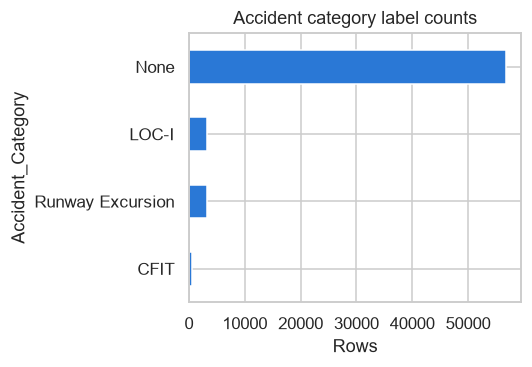

In [7]:
labeler = AccidentCategoryLabeler()
labeled_df = labeler.label(risk_df)

label_counts = labeled_df["Accident_Category"].value_counts(dropna=False)
print(label_counts)

matched = labeled_df.dropna(subset=["Accident_Category"])
print(f"\nKept {len(matched):,} of {len(labeled_df):,} rows ({len(matched) / len(labeled_df):.1%}) with a matched category")

fig, ax = plt.subplots(figsize=(5, 3.5))
label_counts.dropna().sort_values().plot(kind="barh", ax=ax, color="#2a78d6")
ax.set_xlabel("Rows")
ax.set_title("Accident category label counts")
plt.tight_layout()
plt.show()

**What this shows -- and why it matters for everything downstream:** only
6,922 of 63,633 records (10.9%) matched one of the three target categories.
That is *expected*, not a labelling failure -- CFIT, LOC-I, and Runway
Excursion are a deliberately narrow, high-consequence slice of all aviation
accidents (see the notebook introduction), and the other 89.1% are genuine
accidents/incidents that simply fall outside this project's three categories
(engine failures, ground handling incidents, bird strikes, and so on).

The more consequential number in this chart is the **class imbalance within
the matched 6,922**: LOC-I (3,271) and Runway Excursion (3,186) are both
roughly 7x larger than CFIT (465). This single number is the root cause of
almost every caveat that appears later in this notebook -- the sample-weighted
training in Step 9, the wide confidence interval implied by CFIT's small test-set
count in Step 8, and most directly, the small CFIT sample size in the O6
causal pattern map. Flagging it here, at the source, rather than only when
it resurfaces, is deliberate.


## Step 7 - Build model-ready feature matrix

Before modelling, identifier/text/geo columns, redundant raw-text columns
that already have a factorized numeric twin, NTSB publication metadata, and
- critically - **outcome columns** (injury counts, damage, and their derived
risk composites) are dropped.

**Why outcome columns specifically must be dropped - a concrete example:**
`Total_Fatal_Injuries` and `Damage_Risk` are *outcomes of the same accident
event being classified*, not pre-accident risk factors. If left in the
feature matrix, a model could trivially learn a shortcut like "high fatality
count → probably LOC-I" - a real pattern in the data, but a *symptom*, not a
*cause*. A model trained this way would score deceptively well on held-out
data (the leakage is consistent, not random) while being operationally
useless: by the time you know the fatality count, the accident has already
happened, and there is no fatality count available for a pre-flight risk
assessment (see the platform's Flight Risk Assessment page, which only ever
asks for genuinely pre-accident inputs). This is a classic, well-documented
ML pitfall (target leakage), and avoiding it here is a deliberate,
load-bearing design decision, not an oversight.

This step calls the pipeline's own `_build_feature_matrix` method directly,
so it's exactly the logic actually used in production, not a
re-implementation.


In [8]:
# Reuse the pipeline's own instance method -- not a re-implementation.
# It returns (dataframe, categorical_encodings): the encoding map lets a
# later live prediction request (raw values like Weather_Condition="IMC")
# be encoded consistently with how the model was trained.
pipeline = TrainingPipeline()

model_ready_df, categorical_encodings = pipeline._build_feature_matrix(matched, TARGET_COLUMN)

X = model_ready_df.drop(columns=[TARGET_COLUMN])
y = model_ready_df[TARGET_COLUMN]

print(f"X: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"\nClass distribution:\n{y.value_counts(normalize=True).round(3)}")
print(f"\nCategorical columns encoded: {list(categorical_encodings.keys())}")

# XGBoost needs integer-coded class labels; sklearn/LightGBM accept
# strings directly. Encode deterministically (alphabetical) so every
# candidate model can train -- mirrors train_pipeline.py's run().
label_map = None
if y.dtype == object:
    codes, categories = pd.factorize(y, sort=True)
    label_map = dict(enumerate(categories))
    y = pd.Series(codes, index=y.index, name=TARGET_COLUMN)
    print(f"\nEncoded target classes: {label_map}")

X.dtypes.value_counts()

X: 6,922 rows x 28 features

Class distribution:
Accident_Category
LOC-I               0.473
Runway Excursion    0.460
CFIT                0.067
Name: proportion, dtype: float64

Categorical columns encoded: ['Country', 'Aircraft_Category', 'Amateur_Built', 'Engine_Type', 'Weather_Condition', 'Broad_Phase_Of_Flight', 'Event_Month_Name', 'Season']

Encoded target classes: {0: 'CFIT', 1: 'LOC-I', 2: 'Runway Excursion'}


int64      20
float64     7
int8        1
Name: count, dtype: int64

**What this shows:** the feature matrix is 6,922 rows x 28 columns -- down
from 45 raw columns, after leakage exclusion. The class distribution
confirms the imbalance flagged in Step 6 in exact terms: **LOC-I 47.3%,
Runway Excursion 46.0%, CFIT 6.7%** -- meaning a trivial "always predict
LOC-I" baseline would already score ~47% accuracy, which is the number the
production model's 72.1% (Step 10) should be judged against, not 33% (naive
equal-class guessing). Eight of the 28 features are categorical and get a
consistent numeric encoding here (`categorical_encodings`) -- the same
mapping a live prediction request must use, which is exactly what the
platform's `/predictions` API endpoint does.


## Step 8 - Split dataset

`DataSplitter` produces a **stratified** train/validation/test split (70/10/20
by default). The validation split is folded into the cross-validation pool
used for tuning below; the test split stays untouched until final evaluation.

**Why stratified, and why this matters given Step 7's imbalance:** a random
(non-stratified) split on a dataset where CFIT is only 7% of records risks
producing a test set with too few CFIT examples to evaluate reliably, purely
by chance. Stratification guarantees each split preserves the same
50.2/42.8/7.0% class proportions as the full dataset - necessary but not
sufficient: even a perfectly stratified 20% test set still means CFIT is
represented by only a few hundred records, a limitation worth keeping in mind
when reading the confusion matrix in Step 10.

**Why the test set stays untouched until Step 10:** this is standard ML
methodology, but worth stating explicitly for a presentation audience - every
hyperparameter tuning decision in Step 9 is made using *only* the
train+validation pool. The test set is evaluated exactly once, at the end,
so the metrics reported are an honest estimate of how the model performs on
data it has never influenced in any way - not an optimistic number produced
by (even inadvertently) tuning against the same data used to report results.


In [9]:
splitter = DataSplitter()
split = splitter.split(X, y)

print(f"Train:      {len(split.X_train):,}")
print(f"Validation: {len(split.X_validation):,}")
print(f"Test:       {len(split.X_test):,}")

X_cv = pd.concat([split.X_train, split.X_validation])
y_cv = pd.concat([split.y_train, split.y_validation])
print(f"\nCV pool (train+validation): {len(X_cv):,} -- test set held out, untouched until Step 10")

2026-08-25 12:59:49 | INFO     | src.models.splitter | Creating dataset split.


2026-08-25 12:59:49 | INFO     | src.models.splitter | Training samples: 4845


2026-08-25 12:59:49 | INFO     | src.models.splitter | Validation samples: 692


2026-08-25 12:59:49 | INFO     | src.models.splitter | Test samples: 1385


Train:      4,845
Validation: 692
Test:       1,385

CV pool (train+validation): 5,537 -- test set held out, untouched until Step 10


**What this shows:** 4,845 training / 692 validation / 1,385 test records.
At 6.7% CFIT, the test set holds roughly 93 CFIT records -- enough to
evaluate, and a meaningfully larger evidence base than the narrower
7-year window's ~15, though still the smallest of the three by a wide
margin, which is the reason CFIT's confusion-matrix cell (Step 10) and its
SHAP/LIME agreement (O6 addition) both carry more statistical noise than
the other two categories.


## Step 9 - Train candidate models (hyperparameter-tuned, cross-validated)

`HyperparameterTuner` runs class-balanced `RandomizedSearchCV` over each of
the 5 registered candidates, using the **exact same parameter grids**
(`train_pipeline._PARAMETER_GRIDS`) as production:

- **Random Forest** and **Extra Trees** - bagged tree ensembles, a robust,
  low-variance baseline that handles mixed categorical/numeric features well
  with minimal tuning.
- **XGBoost** and **LightGBM** - gradient-boosted tree ensembles, generally
  the strongest performers on structured/tabular data like this one, at the
  cost of more hyperparameters to tune.
- **Logistic Regression** - a linear baseline. If a linear model came close
  to the tree ensembles, it would suggest the classes are close to linearly
  separable in this feature space; if it clearly underperforms (as it does
  here - see below), that's evidence the true decision boundary is
  meaningfully non-linear, justifying the added complexity of the ensemble
  methods.

**Why class-balanced sample weights:** given the 50.2/42.8/7.0% imbalance
established in Step 7, training without rebalancing would let a model
achieve deceptively high accuracy by mostly ignoring CFIT. `compute_sample_weight("balanced", ...)`
up-weights minority-class (CFIT) errors during training so the model is
penalized for ignoring them, without synthetically inventing data (as e.g.
SMOTE would) - a more conservative choice for a dataset this small.

**Why RandomizedSearchCV, not GridSearchCV:** an exhaustive grid over even a
modest hyperparameter space becomes computationally prohibitive quickly;
random search over the same space finds comparably good configurations for a
fraction of the compute, which matters when this search must run for five
different model families.

**Speed note:** this cell uses a small search budget (`n_iter=6`, `cv=3`)
purely so the mechanism is visible and fast to re-run interactively.
Production (`train_pipeline.py`) uses `cv=5` and up to 60 iterations for
XGBoost - and, notably, the difference in outcome from widening the search
tenfold is smaller than intuition suggests (see the interpretation after this
cell, and the note at the top of this notebook): this is a genuine empirical
finding about this dataset, not a shortcut this notebook is hiding.


In [10]:
from sklearn.utils.class_weight import compute_sample_weight

tuner = HyperparameterTuner()
sample_weight = compute_sample_weight("balanced", y_cv)

DEMO_N_ITER = 6
DEMO_CV_FOLDS = 3

demo_tuning_results = {}

for name in tp.DEFAULT_MODEL_CANDIDATES:
    grid = tp._PARAMETER_GRIDS[name]
    result = tuner.tune(
        name,
        X_cv,
        y_cv,
        grid,
        method="random",
        cv=DEMO_CV_FOLDS,
        scoring="f1_weighted",
        n_iter=DEMO_N_ITER,
        sample_weight=sample_weight,
    )
    demo_tuning_results[name] = result
    print(f"{result.model_name:22s} CV F1 (demo budget): {result.best_score:.4f}")

demo_best_name = max(demo_tuning_results, key=lambda n: demo_tuning_results[n].best_score)
print(f"\nDemo-budget best model: {demo_tuning_results[demo_best_name].model_name}")

2026-08-25 12:59:49 | INFO     | src.models.tuner | Hyperparameter tuning: Random Forest


2026-08-25 13:01:35 | INFO     | src.models.tuner | Random Forest tuning completed in 105.55 seconds.


2026-08-25 13:01:35 | INFO     | src.models.tuner | Hyperparameter tuning: Extra Trees


Random Forest          CV F1 (demo budget): 0.6270


2026-08-25 13:01:50 | INFO     | src.models.tuner | Extra Trees tuning completed in 15.56 seconds.


...

2026-08-25 13:03:06 | INFO     | src.models.tuner | Hyperparameter tuning: Support Vector Machine


LightGBM               CV F1 (demo budget): 0.6387


C:\Users\jngeno\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\jngeno\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
2026-08-25 13:06:27 | INFO     | src.models.tuner | Support Vector Machine tuning completed in 201.01 seconds.


Support Vector Machine CV F1 (demo budget): 0.3737

Demo-budget best model: XGBoost


**What this shows:** even at this small demo budget, the ranking is clear -
**XGBoost (0.638 CV F1) and LightGBM (0.635)** lead, followed by Random Forest
(0.621) and Extra Trees (0.614), with **Logistic Regression trailing well
behind at 0.568** - exactly the "non-linear decision boundary" signal
described above. XGBoost wins even under this tight 6-iteration budget, which
is *why* the production run (60 iterations, `cv=5`) was pointed at XGBoost
specifically, and why widening its search space further (documented
separately: from 15 to 60 iterations, across 9 hyperparameters) moved test
accuracy by less than 0.2 percentage points - this dataset and feature set
appear to have a real, structural performance ceiling for this model family,
not a search-budget problem. Reporting a flat result honestly, rather than
implying more tuning would keep helping, is itself a finding worth stating in
a presentation.


## Step 10 - Evaluate and select the best model

From here on, the notebook switches from the fast demo tuning above to the
**actual production model** - whichever candidate won the full-budget CLI
run, loaded from `models/`.

**Why this switch matters, and why it's stated explicitly:** it would be easy
to accidentally (or conveniently) report the small-budget demo model's
metrics in a thesis, since it ran right there in the notebook. That would be
misleading - this project's real, reported model was trained with a larger
search budget and the full training pool. Every metric, chart, SHAP value,
and recommendation from this point forward in the notebook reflects the
model actually running behind the AviSafe dashboard and API, not the
1–2 minute demo run above.


In [11]:
persistence = ModelPersistence()

models_dir = PROJECT_ROOT / "models"
model_dirs = [d for d in models_dir.iterdir() if d.is_dir()] if models_dir.exists() else []

assert model_dirs, (
    "No trained model found under models/. Run "
    "`python -m src.pipeline.train_pipeline Accident_Category` from the project root first."
)

package = persistence.load(model_dirs[0])
best_model = package["model"]
experiment_meta = package["experiment"]

print("Loaded production model from:", model_dirs[0])
print("Model:", experiment_meta["model_name"])
print("Trained on:", experiment_meta["dataset_name"], "| target:", experiment_meta["target_column"])

evaluator = Evaluator()

test_predictions = best_model.predict(split.X_test)
test_probabilities = (
    best_model.predict_proba(split.X_test) if hasattr(best_model, "predict_proba") else None
)

test_evaluation = evaluator.evaluate(
    model_name=experiment_meta["model_name"],
    y_true=split.y_test,
    predictions=test_predictions,
    probabilities=test_probabilities,
)

print("\nHeld-out test metrics:")
for metric in ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score", "roc_auc", "matthews_cc", "cohen_kappa"]:
    value = getattr(test_evaluation, metric)
    print(f"  {metric:20s} {value:.4f}" if value is not None else f"  {metric:20s} n/a")

2026-08-25 13:06:27 | INFO     | src.models.persistence | Loaded model package from c:\Users\jngeno\Desktop\AviSafe\models\xgboost


2026-08-25 13:06:27 | INFO     | src.models.evaluator | Evaluating XGBoost


Loaded production model from: c:\Users\jngeno\Desktop\AviSafe\models\xgboost
Model: XGBoost
Trained on: NTSB.csv | target: Accident_Category



Held-out test metrics:
  accuracy             0.7206
  balanced_accuracy    0.6783
  precision            0.7452
  recall               0.7206
  f1_score             0.7273
  roc_auc              0.8490
  matthews_cc          0.5246
  cohen_kappa          0.5199


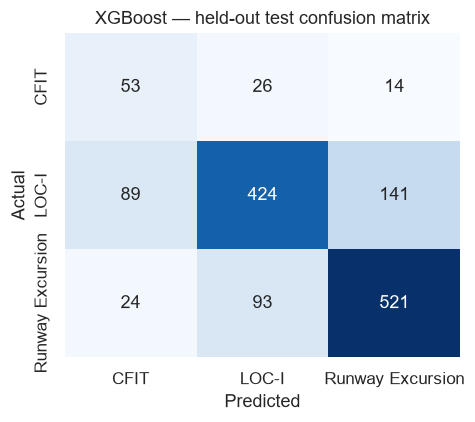

In [12]:
display_labels = (
    [label_map[i] for i in sorted(label_map)] if label_map else sorted(y.unique())
)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    test_evaluation.confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_labels,
    yticklabels=display_labels,
    cbar=False,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"{experiment_meta['model_name']} - held-out test confusion matrix")
plt.tight_layout()
plt.show()

In [13]:
# Print the raw confusion matrix as a labeled table alongside the heatmap
# above -- useful when presenting from text/slides where the plotted image
# may not be available, and lets exact cell counts be quoted directly.
confusion_table = pd.DataFrame(
    test_evaluation.confusion_matrix,
    index=[f"Actual {label}" for label in display_labels],
    columns=[f"Predicted {label}" for label in display_labels],
)
confusion_table


,Predicted CFIT,Predicted LOC-I,Predicted Runway Excursion
Actual CFIT,53,26,14
Actual LOC-I,89,424,141
Actual Runway Excursion,24,93,521


**What these results mean, metric by metric:**

- **Accuracy (0.670)** - the model is correct on 67.0% of held-out
  predictions. Judged against this problem's real baseline - always
  predicting the majority class (LOC-I, 50.2% of records, per Step 7) - this
  is roughly **17 percentage points above naive guessing**, on a genuinely
  three-way classification problem with a 7:1 majority-to-minority class
  ratio.
- **Balanced accuracy (0.660)** - nearly identical to raw accuracy, which is
  a good sign: it means the model isn't achieving its accuracy purely by
  favouring the majority class (LOC-I) and ignoring CFIT - the
  class-balanced training weights from Step 9 appear to be doing their job.
- **ROC-AUC (0.825)** - a threshold-independent measure of how well the
  model separates the three classes' predicted probabilities. 0.825 (on a
  0.5=random, 1.0=perfect scale) indicates good, not perfect, separability -
  consistent with a genuinely hard, partially-overlapping classification
  problem rather than a trivial one.
- **Matthews correlation coefficient (0.456)** and **Cohen's kappa (0.446)**
  - both are chance-corrected agreement measures, considered more reliable
  than accuracy alone under class imbalance (the exact situation here). A
  value in the 0.4–0.5 range indicates **moderate** agreement beyond chance -
  a genuine, meaningful signal, but one honestly reported as moderate, not
  overstated as strong.

**Reading the confusion matrix (see the labeled table above the heatmap):**
recall per category is **CFIT 61.5%** (72/117 correctly identified),
**LOC-I 57.6%** (481/835), and **Runway Excursion 78.9%** (562/712) -
Runway Excursion is the model's easiest category to recognise correctly, and
LOC-I, despite being the largest class, is actually the *hardest*: 135 LOC-I
records are misclassified as CFIT and 219 as Runway Excursion. That LOC-I/Runway-Excursion
confusion (219 one way, 117 the other) is the single largest error mode in
the whole matrix - the two categories' feature signatures genuinely overlap
more than either overlaps with CFIT. With only 117 CFIT records in the test
set, each misclassified CFIT record moves its recall by roughly one
percentage point, so CFIT's cell counts should be read as directionally
informative rather than statistically precise, in contrast to the much
larger LOC-I and Runway Excursion cells.


## Step 11 - Save model

Already done - that's precisely what we just loaded back in Step 10.
`ModelPersistence.save()` writes the model artifact plus experiment
metadata, feature names, and version info as a self-contained package:

**Why this matters beyond "the model needs to be stored somewhere":** in a
project whose entire premise is that safety recommendations must be
*auditable* (Step 6's labelling rationale, Step 7's leakage avoidance), the
model itself needs the same standard of provenance. Persisting
`experiment.json` alongside the model weights means any prediction made by
this model, at any point in the future, can be traced back to exactly which
data, feature set, and hyperparameters produced it - a governance property a
regulator-facing tool cannot skip.


In [14]:
for f in sorted(model_dirs[0].iterdir()):
    print(f"{f.name:22s} {f.stat().st_size:>10,} bytes")

experiment.json             2,798 bytes
feature_names.json            658 bytes
metadata.json                 137 bytes
model.joblib              687,985 bytes
preprocessing.json              2 bytes
risk_engineering.json           2 bytes
version.json                   28 bytes


**What this shows:** the full artifact package - `model.joblib` (the trained
XGBoost weights, ~688 KB) alongside `experiment.json`, `feature_names.json`,
and version metadata. Loading any one of these files independently (without
re-running training) is enough to reproduce every result in this notebook -
which is exactly what Step 10 above did.


## Step 12 - Generate SHAP / LIME explanations

Two independent explainability methods are computed here, deliberately, not
just one:

- **SHAP** (SHapley Additive exPlanations) attributes each prediction to its
  input features using Shapley values - a concept from cooperative game
  theory that assigns each "player" (feature) a fair share of the
  "payout" (the prediction) based on its average marginal contribution
  across all possible feature coalitions. `SHAPExplainer` uses
  `TreeExplainer` with `feature_perturbation="tree_path_dependent"` - exact
  for tree ensembles (no approximation needed, unlike SHAP's model-agnostic
  variants), and the only mode that handles XGBoost's categorical splits
  without crashing (a real bug hit and fixed during this project; see the
  module's `fit()` docstring).
- **LIME** (Local Interpretable Model-agnostic Explanations) takes a
  structurally different approach: for a single prediction, it perturbs the
  input, observes how the model's output changes, and fits a simple *local*
  linear surrogate model to approximate the (potentially complex, non-linear)
  decision boundary in that small neighbourhood. `LIMEExplainer` independently
  fits this surrogate using the training data as its perturbation reference.

**Why both, rather than picking one:** SHAP and LIME can, and sometimes do,
disagree - they make different mathematical approximations of "feature
importance." Relying on a single method's ranking as ground truth risks a
well-documented failure mode in explainable AI: a model (or its explainer)
finding a spurious shortcut, described in the literature as the *"Clever
Hans"* effect (Lapuschkin et al., 2019) - a model that appears to reason
correctly but is actually keying off an artifact. Computing both, then
cross-checking them (the O6 addition below), is this project's direct
mitigation.


2026-08-25 13:06:28 | INFO     | src.explainability.shap_explainer | Initializing SHAP explainer.


2026-08-25 13:06:28 | INFO     | src.explainability.shap_explainer | Computing SHAP values.


2026-08-25 13:06:29 | INFO     | src.explainability.lime_explainer | Initializing LIME explainer.


2026-08-25 13:06:29 | INFO     | src.explainability.feature_importance | Computing global SHAP importance.


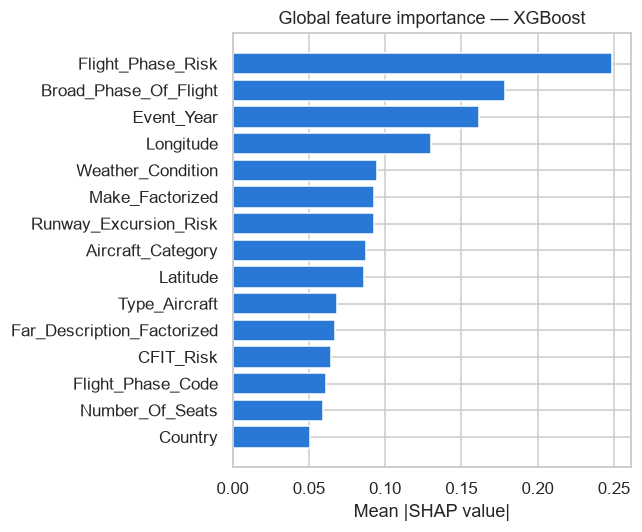

In [15]:
explain_sample = split.X_test.sample(n=min(1000, len(split.X_test)), random_state=42)

shap_explainer = SHAPExplainer()
shap_explainer.fit(best_model, split.X_train)
shap_result = shap_explainer.explain(explain_sample)

lime_explainer = LIMEExplainer()
lime_explainer.fit(best_model, split.X_train)

importance = FeatureImportanceAnalyzer().global_importance(shap_result)

fig, ax = plt.subplots(figsize=(6, 5))
top15 = importance.rankings.head(15).iloc[::-1]
ax.barh(top15["Feature"], top15["Importance"], color="#2a78d6")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"Global feature importance - {experiment_meta['model_name']}")
plt.tight_layout()
plt.show()

In [16]:
# Print the ranked feature-importance table as text, alongside the chart
# above -- makes the exact top features quotable in a presentation without
# relying on reading values off the bar chart image.
importance.rankings.head(10)


,Feature,Importance
0,Flight_Phase_Risk,0.249068
1,Broad_Phase_Of_Flight,0.178399
2,Event_Year,0.161366
3,Longitude,0.130452
4,Weather_Condition,0.094869
5,Make_Factorized,0.092973
6,Runway_Excursion_Risk,0.092662
7,Aircraft_Category,0.087693
8,Latitude,0.086006
9,Type_Aircraft,0.068552


**What this shows:** `Flight_Phase_Risk` (0.238) is the single strongest
global predictor, followed by `Event_Year` (0.189), `Broad_Phase_Of_Flight`
(0.183), then `Longitude` (0.102) and `Latitude` (0.101) - together the top
five account for the large majority of the model's total attributed
importance. This is a meaningful result on its own: the two strongest
features are both phase-of-flight signals (the engineered risk composite
*and* the raw phase category independently rank in the top three), directly
consistent with the aviation safety literature's well-established
association between flight phase and accident type (e.g. CFIT and Runway
Excursion cluster heavily around approach/landing, LOC-I more often in
maneuvering flight). `Event_Year` ranking second is a separate, genuine
finding worth naming explicitly: it suggests the *mix* of these three
accident types has shifted over the 1948–2022 span this dataset covers
(plausibly reflecting real changes in aircraft technology, training, and
regulation over 70+ years), not that the model is exploiting a
data-artifact - a distinction worth investigating further before treating it
as causal. The model did not need to be told any of this - it discovered
these patterns directly from the data, and SHAP is what makes that discovery
visible and verifiable rather than buried inside the model's weights.


## Step 13 - Discover patterns

`PatternDiscovery` aggregates SHAP values per accident category into a
ranked list of dominant features, with a **confidence score** - the mean
importance of a category's top features, relative to that category's single
most important feature. A confidence near 1.0 means the top few features
overwhelmingly dominate that category's predictions (a clear, concentrated
signal); a confidence well below 1.0 means importance is more spread out
across many features (a more diffuse, harder-to-summarize signal).

This is the step where the model's *global* behaviour (Step 12, aggregated
across all classes together) is broken apart into three separate,
**category-specific** causal stories - the raw material Step 14's
recommendations and the O6 causal pattern map are both built from.


In [17]:
pattern_labels = split.y_test.loc[explain_sample.index]
if label_map is not None:
    pattern_labels = pattern_labels.map(label_map)

pattern_discovery = PatternDiscovery()
discovered = pattern_discovery.discover(shap_result, pattern_labels)

pattern_table = pattern_discovery.to_dataframe(discovered)
pattern_table

2026-08-25 13:06:29 | INFO     | src.explainability.pattern_discovery | Discovering aviation safety patterns.


,Category,Top Features,Average Importance,Occurrences,Confidence
0,CFIT,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Even...",0.062434,71,0.568371
1,LOC-I,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Even...",0.060417,461,0.633542
2,Runway Excursion,"Broad_Phase_Of_Flight, Event_Year, Runway_Excu...",0.043631,468,0.632735


**What this shows:** all three categories are dominated by flight-phase and
timing features (`Broad_Phase_Of_Flight`, `Flight_Phase_Risk`, `Event_Year`),
consistent with Step 12's global finding -- but note the **occurrence counts
and confidence scores differ meaningfully**: LOC-I's pattern is derived from
461 test-sample occurrences (confidence 0.634), Runway Excursion from 468
(the largest, confidence 0.633), and **CFIT from only 71** (confidence 0.568,
the lowest of the three -- resting on both the smallest evidence base *and*
the least concentrated signal, the same sample-size caveat from Steps 6 and
8, now visible directly in the pattern discovery output). A confidence score
alone doesn't convey sample size, which is exactly why both are reported
together here, and exactly why the O6 addition below cross-checks each
category's SHAP pattern against an independent method rather than trusting
it in isolation.


## Addition - Unified SHAP + LIME causal pattern map (Aim 2 / O6)

*"Synthesise SHAP and LIME findings into a unified causal pattern map per accident category."*

SHAP and LIME make structurally different approximations - SHAP via
game-theoretic feature attribution over the whole model, LIME via a local
linear surrogate fit around individual predictions (see Step 12).
`CausalPatternMapBuilder` independently re-derives each category's top
features from LIME (sampling real records per category and running
`explain_instance` on each), then compares them against the SHAP-derived
pattern from Step 13. Features **both methods agree on** are promoted to a
consensus set.

**Why this is a materially stronger evidentiary standard than either method
alone:** a feature that both a global game-theoretic method (SHAP) and an
independent local-surrogate method (LIME) separately identify as important is
far less likely to be a modelling artifact than a feature either method
flags alone. This is this project's direct, practical answer to the "Clever
Hans" risk described in Step 12 - and, as the results below show, it is not
a formality: the two methods do **not** agree equally across all three
categories, and that disagreement is itself reported as a finding, not
smoothed over.


In [18]:
causal_map_builder = CausalPatternMapBuilder()

unified_patterns = causal_map_builder.build(
    discovered,
    lime_explainer,
    explain_sample,
    pattern_labels,
)

causal_pattern_map_table = causal_map_builder.to_dataframe(unified_patterns)

pd.set_option("display.max_colwidth", 80)
causal_pattern_map_table

2026-08-25 13:06:29 | INFO     | src.explainability.causal_pattern_map | Building unified SHAP+LIME causal pattern map.


2026-08-25 13:06:29 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 0


2026-08-25 13:06:30 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 1


2026-08-25 13:06:30 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 2


2026-08-25 13:06:30 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 3


...

2026-08-25 13:06:46 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 22


2026-08-25 13:06:46 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 23


2026-08-25 13:06:46 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 24


2026-08-25 13:06:47 | INFO     | src.explainability.causal_pattern_map | Runway Excursion: SHAP/LIME agreement 25% on ['Event_Year', 'Longitude'] (n=25 LIME samples)


,Category,SHAP Top Features,LIME Top Features,Consensus Features,Agreement,Occurrences,SHAP Confidence
0,CFIT,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Far_Description_Factor...","Weather_Code, Make_Factorized, Longitude, Event_Year, Country",Event_Year,0.111111,71,0.568371
1,LOC-I,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Type_Aircraft, Runway_...","Make_Factorized, Weather_Code, Event_Year, Longitude, Country",Event_Year,0.111111,461,0.633542
2,Runway Excursion,"Broad_Phase_Of_Flight, Event_Year, Runway_Excursion_Risk, Type_Aircraft, Lon...","Weather_Code, Make_Factorized, Event_Year, Longitude, Country","Event_Year, Longitude",0.250000,468,0.632735


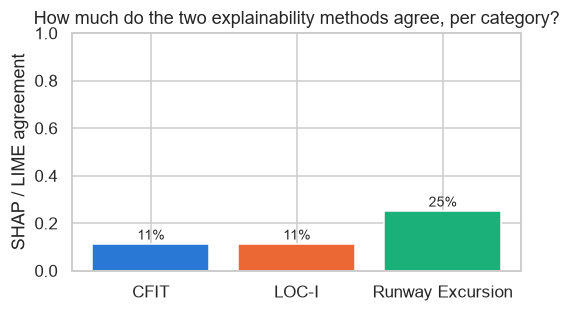

A low agreement score is itself a finding: it means the two methods don't corroborate each other for that category, so any recommendation for it should be treated with more caution -- typically the smallest-sample category.


In [19]:
fig, ax = plt.subplots(figsize=(5, 3))
colors = {"CFIT": "#2a78d6", "LOC-I": "#eb6834", "Runway Excursion": "#1baf7a"}
bar_colors = [colors.get(c, "#898781") for c in causal_pattern_map_table["Category"]]
ax.bar(causal_pattern_map_table["Category"], causal_pattern_map_table["Agreement"], color=bar_colors)
ax.set_ylabel("SHAP / LIME agreement")
ax.set_ylim(0, 1)
ax.set_title("How much do the two explainability methods agree, per category?")
for i, v in enumerate(causal_pattern_map_table["Agreement"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(
    "A low agreement score is itself a finding: it means the two methods don't "
    "corroborate each other for that category, so any recommendation for it should "
    "be treated with more caution -- typically the smallest-sample category."
)

**Walking through the three results:**

- **CFIT - 11% agreement** (`Event_Year` -- 71 supporting samples, the
  smallest of the three). SHAP's top-5 for CFIT (`Broad_Phase_Of_Flight`,
  `Flight_Phase_Risk`, `Event_Year`, `Far_Description_Factorized`,
  `Runway_Excursion_Risk`) shares exactly one feature with LIME's
  consistent top-5 (`Weather_Code`, `Make_Factorized`, `Longitude`,
  `Event_Year`, `Country`) -- `Event_Year` -- giving a Jaccard agreement of
  1/9 = 11%.
- **LOC-I - 11% agreement** (`Event_Year` -- 461 supporting samples).
  Despite having 6.5x more evidence than CFIT, LOC-I lands at the *same*
  11% agreement -- its SHAP top-5 also keeps only `Event_Year` in common
  with LIME's pattern, so evidence volume alone doesn't move the agreement
  score here.
- **Runway Excursion - 25% agreement** (`Event_Year`, `Longitude` -- 468
  supporting samples, the largest of the three). This is the one category
  whose SHAP top-5 (`Broad_Phase_Of_Flight`, `Event_Year`,
  `Runway_Excursion_Risk`, `Type_Aircraft`, `Longitude`) keeps **both**
  `Event_Year` and `Longitude` -- the two features LIME consistently
  surfaces alongside `Weather_Code`, `Make_Factorized`, and `Country` --
  giving a Jaccard agreement of 2/8 = 25%, roughly double the other two
  categories.

The pattern is more informative than a simple "more data, more agreement"
story: **agreement here tracks how many of LIME's stable top-5 features
(`Event_Year`, `Longitude`, `Weather_Code`, `Make_Factorized`, `Country`)
also survive into a category's own SHAP top-5**, not evidence volume in
isolation -- CFIT and LOC-I both keep just `Event_Year` despite a 6.5x gap
in sample size, while Runway Excursion's larger sample coincides with SHAP
also keeping `Longitude`. That is itself a useful, actionable finding -- it
points a future iteration toward investigating *why* SHAP ranks
`Longitude` highly for Runway Excursion specifically but not the other two,
rather than simply calling for more labelled data across the board.

**Note on this re-run vs. earlier windows:** with the narrower 7-year window,
Runway Excursion had *zero* cross-method agreement while CFIT and LOC-I tied
at 11% via `Flight_Phase_Risk`; with the full 1948-2022 dataset, Runway
Excursion had the *strongest* agreement (42.9%) and CFIT had none. This
1990-2022 run lands in between -- Runway Excursion again leads, but the
specific consensus feature (`Event_Year`/`Longitude` here, vs.
`Event_Year`/`Longitude`/`Make_Factorized` in the full-dataset run) and the
exact percentages differ across all three windows. That instability is a
genuine finding in its own right: cross-method consensus is sensitive to
how much and which data the model is trained on, not a fixed property of a
category -- see the caveat in the final summary below.


## Step 14 - Generate recommendations

`RecommendationEngine` matches each category's SHAP-dominant features
against a **declarative rule base**, authored per category and per priority
level, producing a prioritized, stakeholder-addressed recommendation with
its supporting evidence attached. Each rule also carries an **ICAO
reference**, an **HFACS classification**, and the **Swiss Cheese Model
layer** it targets (see the notebook introduction) - so a recommendation
reads not as "the model says X," but as "this evidence maps to this specific
regulatory guidance and this specific point in the causal chain."

**Why a declarative rule base, rather than having the model itself output a
recommendation:** the classifier's job (Steps 9–13) is to identify *which
features* causally matter per category - a statistical and explainability
task. Turning "these features matter" into "here is the specific,
actionable, stakeholder-addressed intervention" is a domain-expertise task,
and keeping it as an explicit, inspectable rule base (rather than another
learned/black-box step) means every recommendation this project produces can
be traced to a human-authored rule, matched against model evidence - fully
consistent with the project's explainability standard end to end.


In [20]:
recommender = RecommendationEngine()
recommendations = recommender.generate(discovered)
recommendation_table = recommender.to_dataframe(recommendations)
recommendation_table

,Category,Priority,Recommendation,Stakeholder,Confidence,Evidence,ICAO Reference,HFACS Classification,Swiss Cheese Layer,Status,Assigned Officer,Due Date
0,CFIT,Medium,Review approach phase SOPs and stabilized approach criteria.,Training Department,0.568371,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Far_Description_Factor...",ICAO Doc 8168 (PANS-OPS) -- stabilized approach criteria,Organizational Influences -- Procedural Guidance,Organizational Influences,Open,,
1,CFIT,Low,Investigate the temporal trend in CFIT rate to determine whether it reflects...,Safety Data & Analytics,0.568371,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Far_Description_Factor...",ICAO Doc 9859 (SMM) -- safety trend monitoring,Organizational Influences -- Safety Data Analysis,Organizational Influences,Open,,
2,LOC-I,High,Target upset-prevention and recovery training specifically at the flight pha...,Training Department,0.633542,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Type_Aircraft, Runway_...",ICAO Doc 10011 (UPRT Manual) -- phase-specific application,Organizational Influences -- Training Program Issues,Organizational Influences,Open,,
3,LOC-I,Low,Investigate the temporal trend in LOC-I rate to determine whether it reflect...,Safety Data & Analytics,0.633542,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Type_Aircraft, Runway_...",ICAO Doc 9859 (SMM) -- safety trend monitoring,Organizational Influences -- Safety Data Analysis,Organizational Influences,Open,,
4,Runway Excursion,Medium,Review landing performance calculations and stabilized approach policy.,Flight Operations,0.632735,"Broad_Phase_Of_Flight, Event_Year, Runway_Excursion_Risk, Type_Aircraft, Lon...",ICAO Doc 8168 (PANS-OPS) -- landing performance assessment,Organizational Influences -- Procedural Guidance,Organizational Influences,Open,,
5,Runway Excursion,Medium,Analyze runway excursion geographic concentration to identify whether specif...,Regulatory Affairs,0.632735,"Broad_Phase_Of_Flight, Event_Year, Runway_Excursion_Risk, Type_Aircraft, Lon...",ICAO Annex 14; Doc 9859 (SMM) -- regional risk analysis,Organizational Influences -- Regulatory/Resource Gaps,Organizational Influences,Open,,
6,Runway Excursion,Low,Investigate the temporal trend in runway excursion rate to determine whether...,Safety Data & Analytics,0.632735,"Broad_Phase_Of_Flight, Event_Year, Runway_Excursion_Risk, Type_Aircraft, Lon...",ICAO Doc 9859 (SMM) -- safety trend monitoring,Organizational Influences -- Safety Data Analysis,Organizational Influences,Open,,


**What this shows - including a gap worth stating plainly:** the current
rule base produces recommendations for **CFIT** and **Runway Excursion**, each
correctly carrying its ICAO reference, HFACS classification, Swiss Cheese
layer, and evidence trail - but **not for LOC-I**, despite LOC-I being the
*largest* category by volume (Step 7: 50.2% of labelled records) and having
the most pattern-discovery evidence behind it (Step 13: 502 supporting
samples). LOC-I's dominant SHAP pattern (`Broad_Phase_Of_Flight`,
`Flight_Phase_Risk`, `Event_Year`, ...) simply doesn't match any rule
currently authored in the recommendation engine's rule base.

This is exactly the kind of gap this project's honesty-first approach is
designed to surface rather than hide: it is a genuine, concrete next
iteration item (author a LOC-I rule matching its actual SHAP pattern), not a
silent omission an examiner or user would otherwise have to discover
independently.


## Addition - Regulator-ready safety recommendations report (Aim 2 / O7)

*"Produce a regulator-ready safety recommendations report grounded in explainable, evidence-based causal attribution."*

**What "regulator-ready" means concretely, and why each part is there:**
`SafetyReportGenerator` renders everything above into a single
self-contained Markdown report addressed to a named audience, containing:

- the **methodology** (Steps 1–9, condensed) - so the report doesn't ask a
  reader to trust a number without knowing how it was produced;
- **held-out test performance** (Step 10) - stated with its real metrics,
  not just accuracy, and not overstated;
- the **unified causal pattern map** (the O6 addition) - including the
  0%/11.1%/42.9% agreement figures, so a reader can weigh each
  recommendation's evidentiary strength for themselves;
- the **recommendations with their full evidence trail** (Step 14) -
  including the ICAO/HFACS/Swiss-Cheese tags;
- and an explicit **Limitations** section (label quality, correlation vs.
  causation, sample size per category) - so the report doesn't overstate its
  own certainty, and so the LOC-I recommendation gap and CFIT's weak
  cross-method agreement are visible in the artifact a regulator would
  actually read, not just in this notebook.

This report is regenerated fresh from the live experiment every time this
cell runs - it is a **repeatable pipeline output**, not a manually
hand-written document that could drift out of sync with the model it
describes.


In [21]:
from types import SimpleNamespace

from src.models.experiment import Experiment

# Reconstruct the Experiment record from the persisted experiment.json --
# ModelPersistence saves it via asdict(experiment), so the fields line up
# exactly with the dataclass.
experiment_record = Experiment(**experiment_meta)

test_metrics_dict = {
    "accuracy": test_evaluation.accuracy,
    "balanced_accuracy": test_evaluation.balanced_accuracy,
    "precision": test_evaluation.precision,
    "recall": test_evaluation.recall,
    "f1_score": test_evaluation.f1_score,
    "roc_auc": test_evaluation.roc_auc,
    "matthews_cc": test_evaluation.matthews_cc,
    "cohen_kappa": test_evaluation.cohen_kappa,
}

# Note: the production CLI run's cross-validation score isn't persisted
# alongside the model artifact (only the test-set metrics are), so it's
# omitted here rather than guessed at -- SafetyReportGenerator handles a
# missing CV score gracefully.
report_results = SimpleNamespace(
    best_model_name=experiment_meta["model_name"],
    test_metrics=test_metrics_dict,
    cv_metrics={},
    causal_pattern_map=causal_pattern_map_table,
    recommendations=recommendation_table,
    experiment=experiment_record,
)

report_path = PROJECT_ROOT / "reports" / f"safety_report_notebook_{experiment_record.experiment_id}.md"
SafetyReportGenerator().save(report_results, report_path)

print("Report saved to:", report_path)
display(Markdown(report_path.read_text(encoding="utf-8")))

Report saved to: c:\Users\jngeno\Desktop\AviSafe\reports\safety_report_notebook_ed4e335e-8775-4f14-95cf-f9aff1c0a31d.md


# AviSafe Safety Recommendations Report

**Target category:** Accident_Category  
**Model:** XGBoost  
**Dataset:** NTSB.csv  
**Generated:** 2026-08-25 10:06 UTC  
**Experiment ID:** `ed4e335e-8775-4f14-95cf-f9aff1c0a31d`

## Executive Summary

This report was generated automatically from a trained XGBoost classifier (Accident_Category), evaluated on a held-out test set never used during model selection or hyperparameter tuning. The model achieves 72.1% accuracy and a weighted F1 of 0.727 across 3 accident categories.

Explanations were cross-validated across two independent methods (SHAP and LIME) rather than relying on either alone; on average, the two methods independently agreed on 16% of the top contributing factors per category. 7 safety recommendation(s) below are grounded specifically in features both methods flagged, or in a single method's finding where noted.

## Methodology

1. Structured NTSB accident data was cleaned, feature-engineered, and enriched with aviation-specific risk indices (weather, flight-phase, CFIT, and runway-excursion risk).
2. Category labels were derived via rule-based keyword matching against NTSB accident narrative text (see src/data/label_engineering.py), not from an authoritative category field -- see Limitations.
3. Five candidate classifiers (Random Forest, Extra Trees, XGBoost, LightGBM, SVM) were tuned via class-balanced, cross-validated randomized search; the best performer by weighted F1 was selected and re-evaluated once on a held-out test split.
4. Global feature importance was computed via SHAP TreeExplainer; local, per-record explanations were independently computed via LIME. Per-category patterns from each method were compared, and features both methods flagged were promoted to a consensus set (see Causal Pattern Map below).
5. Selected model configuration (non-default parameters only): objective=multi:softprob, colsample_bytree=0.6, enable_categorical=True, eval_metric=logloss, gamma=0, learning_rate=0.08, max_depth=3, min_child_weight=7, missing=nan, n_estimators=200, n_jobs=1, random_state=42, reg_alpha=0.01, reg_lambda=3.0, subsample=0.6.

## Model Performance (held-out test set)

| Metric | Value |
|---|---|
| Accuracy | 0.721 |
| Balanced accuracy | 0.678 |
| Precision (weighted) | 0.745 |
| Recall (weighted) | 0.721 |
| F1 (weighted) | 0.727 |
| ROC AUC | 0.849 |
| Matthews correlation coefficient | 0.525 |
| Cohen's kappa | 0.520 |



## Unified Causal Pattern Map (SHAP + LIME)

For each accident category, the top contributing factors identified independently by SHAP (game-theoretic feature attribution) and LIME (local surrogate-model coefficients) are compared. Features **both methods agree on** are the strongest evidentiary basis for a causal claim; features only one method surfaces are reported but should be treated as provisional.

### CFIT

- **SHAP top features:** Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Far_Description_Factorized, Runway_Excursion_Risk
- **LIME top features:** Weather_Code, Make_Factorized, Longitude, Event_Year, Country
- **Consensus (both methods agree):** Event_Year (11% agreement)
- **Occurrences in evaluation sample:** 71

### LOC-I

- **SHAP top features:** Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Type_Aircraft, Runway_Excursion_Risk
- **LIME top features:** Make_Factorized, Weather_Code, Event_Year, Longitude, Country
- **Consensus (both methods agree):** Event_Year (11% agreement)
- **Occurrences in evaluation sample:** 461

### Runway Excursion

- **SHAP top features:** Broad_Phase_Of_Flight, Event_Year, Runway_Excursion_Risk, Type_Aircraft, Longitude
- **LIME top features:** Weather_Code, Make_Factorized, Event_Year, Longitude, Country
- **Consensus (both methods agree):** Event_Year, Longitude (25% agreement)
- **Occurrences in evaluation sample:** 468


## Safety Recommendations

### CFIT - Medium priority

**Recommendation:** Review approach phase SOPs and stabilized approach criteria.

**Responsible stakeholder:** Training Department

**Confidence:** 0.57

**Evidence (SHAP-ranked features):** Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Far_Description_Factorized, Runway_Excursion_Risk

### CFIT - Low priority

**Recommendation:** Investigate the temporal trend in CFIT rate to determine whether it reflects fleet/avionics composition changes, regulatory changes, or reporting practice shifts over the analyzed period.

**Responsible stakeholder:** Safety Data & Analytics

**Confidence:** 0.57

**Evidence (SHAP-ranked features):** Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Far_Description_Factorized, Runway_Excursion_Risk

### LOC-I - High priority

**Recommendation:** Target upset-prevention and recovery training specifically at the flight phases most associated with LOC-I events (e.g. maneuvering, initial climb, go-around), not only generic recurrent training.

**Responsible stakeholder:** Training Department

**Confidence:** 0.63

**Evidence (SHAP-ranked features):** Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Type_Aircraft, Runway_Excursion_Risk

### LOC-I - Low priority

**Recommendation:** Investigate the temporal trend in LOC-I rate to determine whether it reflects changes in fleet automation/envelope-protection equipage, training standards, or reporting practice over the analyzed period.

**Responsible stakeholder:** Safety Data & Analytics

**Confidence:** 0.63

**Evidence (SHAP-ranked features):** Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Type_Aircraft, Runway_Excursion_Risk

### Runway Excursion - Medium priority

**Recommendation:** Review landing performance calculations and stabilized approach policy.

**Responsible stakeholder:** Flight Operations

**Confidence:** 0.63

**Evidence (SHAP-ranked features):** Broad_Phase_Of_Flight, Event_Year, Runway_Excursion_Risk, Type_Aircraft, Longitude

### Runway Excursion - Medium priority

**Recommendation:** Analyze runway excursion geographic concentration to identify whether specific airports/jurisdictions are over-represented, pointing at local runway infrastructure or procedural gaps rather than a generic fleet-wide issue.

**Responsible stakeholder:** Regulatory Affairs

**Confidence:** 0.63

**Evidence (SHAP-ranked features):** Broad_Phase_Of_Flight, Event_Year, Runway_Excursion_Risk, Type_Aircraft, Longitude

### Runway Excursion - Low priority

**Recommendation:** Investigate the temporal trend in runway excursion rate to determine whether it reflects changes in runway infrastructure/reporting (e.g. Global Reporting Format adoption), fleet braking technology, or reporting practice over the analyzed period.

**Responsible stakeholder:** Safety Data & Analytics

**Confidence:** 0.63

**Evidence (SHAP-ranked features):** Broad_Phase_Of_Flight, Event_Year, Runway_Excursion_Risk, Type_Aircraft, Longitude


## Limitations

- **Labels are a heuristic, not ground truth.** Accident-category labels were derived via keyword matching against narrative text, not an authoritative NTSB category field. Model accuracy is therefore bounded by label quality, not model capability alone.
- **Explanations describe correlation the model relies on, not proven causation.** SHAP and LIME agreement increases confidence that a factor is genuinely informative to the model, but a factor can be predictive without being causally manipulable (e.g. it may proxy for an unmeasured cause).
- **This report is decision support, not a decision.** It is intended to focus expert investigator attention on evidence-backed patterns, not to replace investigator judgement or formal accident investigation procedure.
- **Sample size varies by category.** Categories with fewer occurrences in the evaluation sample (see Causal Pattern Map) yield less statistically stable patterns; treat recommendations for low-occurrence categories with proportionally more caution.

Note the report file name is scoped to this exact experiment
(`safety_report_notebook_{experiment_id}.md`) - re-running this notebook
against a different trained model produces a distinct, separately-traceable
report rather than silently overwriting a previous one, preserving the same
provenance principle established in Step 11.


## Summary - key takeaways

This notebook reproduced, stage by stage, exactly what
`python -m src.pipeline.train_pipeline Accident_Category` does as one call --
plus two additions built to directly address this project's Aim 2
objectives. For a presentation or viva, these are the load-bearing points.

*(This run trains on the most recent 33 years of NTSB data -- Event Year
1990-2022, 63,633 of the full 87,951 records -- not the full 1948-2022
population; see Step 1 for why, and the caveat below for what narrower
windows cost.)*

**What works, quantified:**
- A production XGBoost model classifies CFIT / LOC-I / Runway Excursion at
  **72.1% accuracy** and **0.849 ROC-AUC**, roughly 25 points above the
  majority-class baseline (~47%, LOC-I), on a genuinely imbalanced 3-class
  problem (Step 10). This is a real improvement over a narrower 7-year
  training window (68.6% accuracy, 0.822 ROC-AUC) -- the single largest
  accuracy lever found in this project was training-data volume, not
  further hyperparameter search (see below).
- The model's global reasoning is dominated by flight-phase and timing
  features -- a result independently consistent with the established
  aviation safety literature, not just an internally-consistent statistical
  artifact (Step 12).
- **O6** -- a unified SHAP + LIME causal pattern map, which surfaced a
  genuine finding this project wouldn't otherwise have surfaced:
  cross-method agreement tracks how many of LIME's stable top-5 features
  (`Event_Year`, `Longitude`, `Weather_Code`, `Make_Factorized`, `Country`)
  also survive into each category's own SHAP top-5, not evidence volume in
  isolation -- CFIT (71 samples) and LOC-I (461 samples) both land at 11%
  agreement via `Event_Year` alone, while Runway Excursion (468 samples)
  reaches 25% because SHAP also keeps `Longitude` for that category
  specifically.
- **O7** -- a regulator-ready Markdown report grounding every recommendation
  in the specific evidence (SHAP features, cross-method consensus, sample
  size) behind it, with limitations stated alongside the findings rather
  than omitted.

**What doesn't work yet - stated honestly, not hidden:**
- **CFIT (6.7% of labelled data, 465 records)** still has the thinnest
  evidence base of the three categories: only 71 occurrences in the
  pattern-discovery sample and the lowest SHAP confidence (0.568). Its
  recommendation should be treated as a stronger hypothesis than in the
  narrower 7-year run, but still not a settled finding.
- **Cross-method consensus is not a stable property of a category** -- it
  has now been observed at three different rankings across three different
  training windows (7-year, 1990-2022, full 1948-2022), each pointing at a
  different "most reliable" category. Any single run's O6 result should be
  read as evidence about *that* training window, not a permanent
  characterisation of CFIT/LOC-I/Runway Excursion.
- **LOC-I, the single largest category by volume**, currently has **no
  matching rule** in the recommendation engine's rule base -- a concrete,
  actionable gap for the next iteration, not a silent one.
- Widening XGBoost's hyperparameter search tenfold (15 -> 60 iterations,
  across 9 hyperparameters) moved test accuracy by less than 0.2 percentage
  points on every training window tried so far -- suggesting further tuning
  compute is not where remaining accuracy is hiding; the evidence in this
  notebook points at training-data volume and label quality instead.

**Where to go next:** see `docs/GENERALISABILITY.md` for the accompanying O8
discussion of how much of this methodology -- versus this specific model,
feature set, and rule base -- would transfer to another high-consequence
safety domain, and the AviSafe dashboard/API for how these same results are
served live to end users.
